# Random Forest Classification

In this exercise we will be tuning the RandomForest hyperparameters

Satrt by Importing useful libraries

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

Reading the data which is included in the 'data_banknote_authentication.csv' file

In [9]:
df = pd.read_csv("data_banknote_authentication.csv")
df.head()

,Variance_Wavelet,Skewness_Wavelet,Curtosis_Wavelet,Image_Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


Diving the data into features and labels (X and y)

In [13]:
X = df.drop(["Class"], axis=1)
y=df[["Class"]]

Splitting the data into train and test parts

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Use the RandomForest model with a GridSearch to optimize 'n_estimators', 'max_features' and 'criterion' parameters

In [55]:
from sklearn.preprocessing import StandardScaler

In [57]:
scaler = StandardScaler()

In [59]:
RFC = RandomForestClassifier()

In [61]:
operations = [('scaler',scaler),('RFC',RFC)]

In [63]:
from sklearn.pipeline import Pipeline
pipe = Pipeline(operations)

In [109]:
n_estimators = list(range(2,40))
lists=['gini','entropy']
param_grid = {'n_estimators': n_estimators,
             'max_features':list(range(1,5)),
             'criterion':lists}

In [112]:
from sklearn.model_selection import GridSearchCV
full_search = GridSearchCV(estimator=RFC, 
                           param_grid=param_grid, 
                            n_jobs=-1, scoring = "accuracy")    

In [114]:
full_search.fit(X_train,y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


GridSearchCV(estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_features': [1, 2, 3, 4],
                         'n_estimators': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                          13, 14, 15, 16, 17, 18, 19, 20, 21,
                                          22, 23, 24, 25, 26, 27, 28, 29, 30,
                                          31, ...]},
             scoring='accuracy')

In [115]:
full_search.best_estimator_.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 2,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 13,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

Evaluate the model by displaying a confusion matrix and a classification report 

In [117]:
def report_model(model):
    model_preds = model.predict(X_test)
    print(classification_report(y_test,model_preds))
    print('\n')
    plt.figure(figsize=(12,8),dpi=150)
    plot_tree(model,filled=True,feature_names=X.columns);

In [118]:
from sklearn.tree import plot_tree

In [119]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score

In [120]:
preds = full_search.best_estimator_.predict(X_test)
confusion_matrix(y_test,preds)

array([[229,   0],
       [  2, 181]], dtype=int64)

In [121]:
print(classification_report(y_test,preds))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       229
           1       1.00      0.99      0.99       183

    accuracy                           1.00       412
   macro avg       1.00      0.99      1.00       412
weighted avg       1.00      1.00      1.00       412



In [138]:
y_train

,Class
879,1
783,1
605,0
1253,1
497,0
...,...
1095,1
1130,1
1294,1
860,1


## Choosing correct number of trees

Let's explore if continually adding more trees improves performance...

In [140]:
test_error = []

for n in range(1,40):
    # Use n random trees
    model = RandomForestClassifier(n_estimators=n)
    model.fit(X_train,y_train["Class"])
    test_preds = model.predict(X_test)
    test_error.append(1-accuracy_score(test_preds,y_test))
 

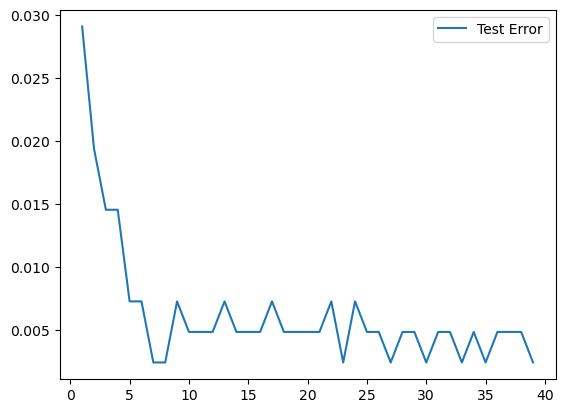

In [142]:
plt.plot(range(1,40),test_error,label='Test Error')
plt.legend()